In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore') # Suppress statsmodels convergence warnings

In [13]:
df = pd.read_csv("KO.csv")
df["Date"] = pd.to_datetime(df["Date"]).dt.tz_localize(None)
df = df.sort_values("Date").reset_index(drop=True)

target_series = df["Close"]
dates = df["Date"]


#### check for stationarity

In [14]:
def check_stationarity(series, title):
    print(f"\n{'='*50}")
    print(f"ADF Test: {title}")
    print(f"{'='*50}")
    
    result = adfuller(series.dropna())
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value:       {result[1]:.4f}")
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value:.4f}")
        
    if result[1] <= 0.05:
        print("\n>>> Conclusion: The series is STATIONARY. (Safe to model) <<<")
        return True
    else:
        print("\n>>> Conclusion: The series is NON-STATIONARY. (Needs transformation) <<<")
        return False

In [15]:
print("STEP A: Testing Raw Prices...")
is_stationary = check_stationarity(target_series, "Raw Close Price")


STEP A: Testing Raw Prices...

ADF Test: Raw Close Price
ADF Statistic: -1.6423
p-value:       0.4611
Critical Values:
   1%: -3.4322
   5%: -2.8624
   10%: -2.5672

>>> Conclusion: The series is NON-STATIONARY. (Needs transformation) <<<


In [16]:
df["Diff_Close"] = target_series.diff()
diff_series = df["Diff_Close"].dropna()

print("\nSTEP B: Testing Transformed Data (1st Difference)...")
check_stationarity(diff_series, "Differenced Close Price")


STEP B: Testing Transformed Data (1st Difference)...

ADF Test: Differenced Close Price
ADF Statistic: -17.9258
p-value:       0.0000
Critical Values:
   1%: -3.4322
   5%: -2.8624
   10%: -2.5672

>>> Conclusion: The series is STATIONARY. (Safe to model) <<<


True

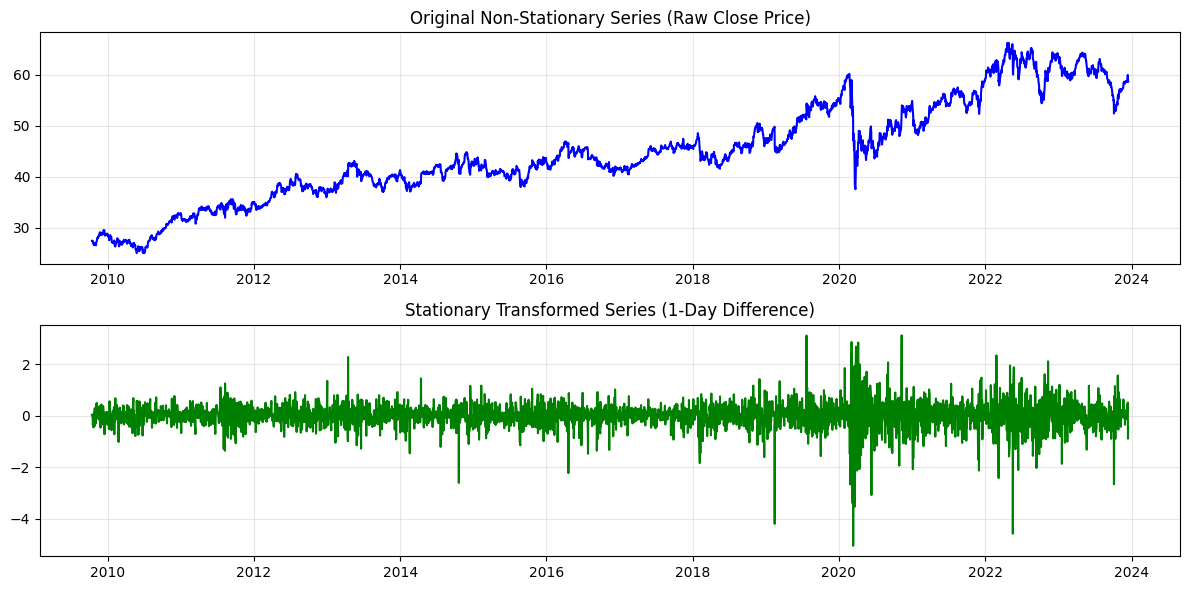

In [17]:
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(dates, target_series, color='blue')
plt.title("Original Non-Stationary Series (Raw Close Price)")
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.plot(dates[1:], diff_series, color='green')
plt.title("Stationary Transformed Series (1-Day Difference)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


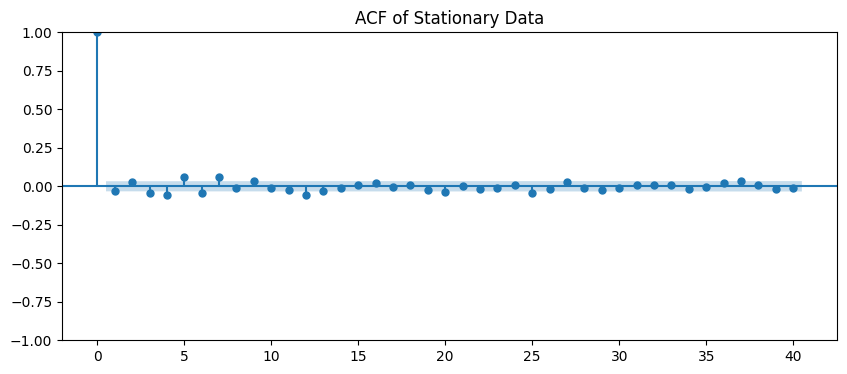

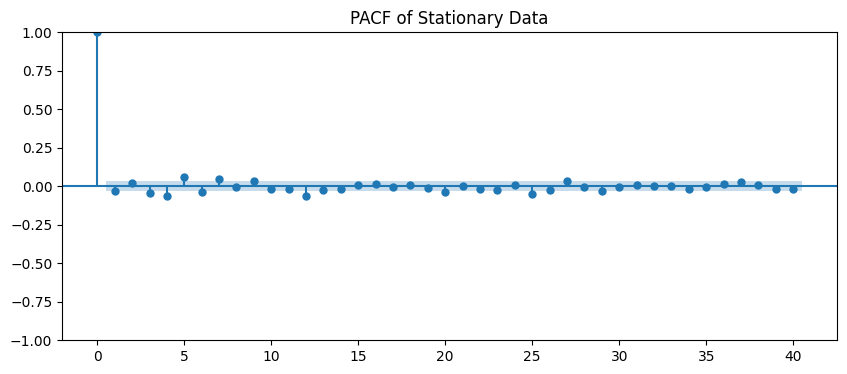

In [18]:
plt.figure(figsize=(10, 4))
plot_acf(diff_series, lags=40, ax=plt.gca(), title="ACF of Stationary Data")
plt.show()

# Plot 3: Partial Autocorrelation (PACF) on Transformed Data
plt.figure(figsize=(10, 4))
plot_pacf(diff_series, lags=40, ax=plt.gca(), title="PACF of Stationary Data")
plt.show()

In [19]:
df_clean = df.dropna().reset_index(drop=True)

split = int(len(df_clean) * 0.8)

train_df = df_clean.iloc[:split]
test_df = df_clean.iloc[split:]

# We train the models on the stationary differences
train_diff = train_df["Diff_Close"].values
test_diff = test_df["Diff_Close"].values
test_dates = test_df["Date"].values

In [20]:
prev_close_actuals = df_clean["Close"].iloc[split-1 : len(df_clean)-1].values
test_actual_close = test_df["Close"].values

print(f"\nTraining points: {len(train_diff)} | Testing points: {len(test_diff)}")


Training points: 2853 | Testing points: 714


In [21]:
def evaluate_and_plot(model_name, actual_prices, predicted_prices, dates):
    mae = mean_absolute_error(actual_prices, predicted_prices)
    mse = mean_squared_error(actual_prices, predicted_prices)
    r2 = r2_score(actual_prices, predicted_prices)
    
    print(f"\n--- {model_name} Evaluation ---")
    print(f"MAE:  {mae:.4f}")
    print(f"MSE:  {mse:.4f}")
    print(f"R2:   {r2:.4f}")
    
    plt.figure(figsize=(12, 5))
    plt.plot(dates, actual_prices, label="Actual Price", color='black', linewidth=1.5)
    plt.plot(dates, predicted_prices, label=f"{model_name} Prediction", color='red', alpha=0.8, linestyle='--')
    plt.title(f"{model_name} Forecast (Reconstructed Prices)")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.gcf().autofmt_xdate()
    plt.show()


Training AR(1) Model on Stationary Data...

--- AR(1) Model Evaluation ---
MAE:  0.4335
MSE:  0.3631
R2:   0.9747


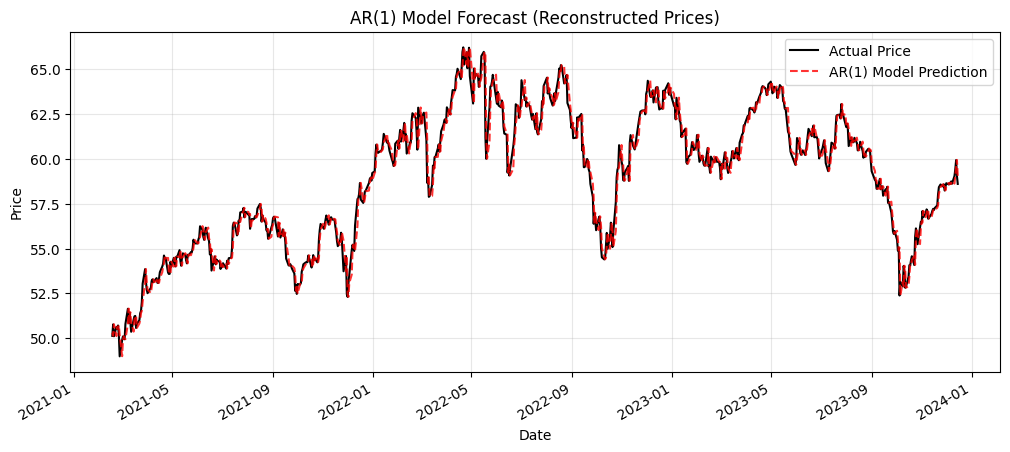

In [22]:
print("\nTraining AR(1) Model on Stationary Data...")
ar1_model = AutoReg(train_diff, lags=1).fit()

# Predict the stationary difference
ar1_diff_preds = ar1_model.predict(start=len(train_diff), end=len(train_diff)+len(test_diff)-1, dynamic=False)

# Reconstruct: Predicted Price = Actual Previous Price + Predicted Difference
ar1_price_preds = prev_close_actuals + ar1_diff_preds

evaluate_and_plot("AR(1) Model", test_actual_close, ar1_price_preds, test_dates)



Training AR(5) Model on Stationary Data...

--- AR(5) Model Evaluation ---
MAE:  0.4335
MSE:  0.3632
R2:   0.9747


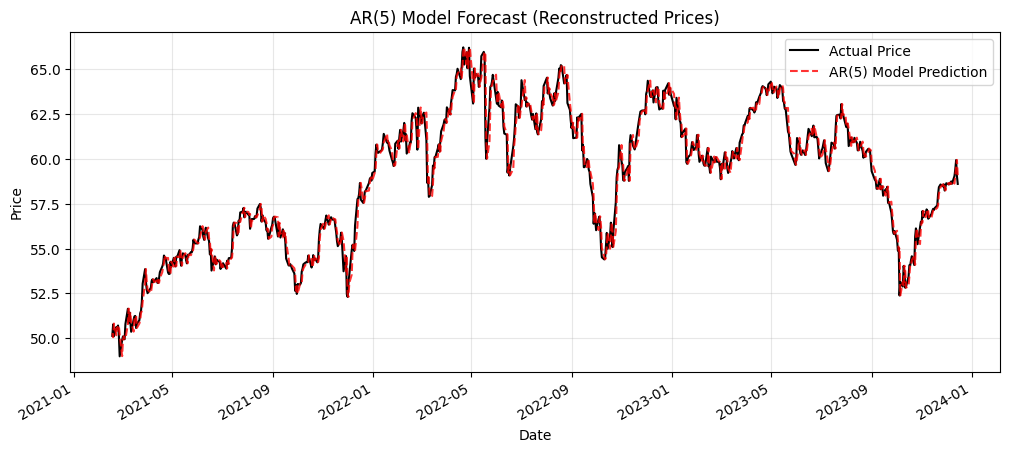

In [23]:
print("\nTraining AR(5) Model on Stationary Data...")
ar5_model = AutoReg(train_diff, lags=5).fit()

# Predict the stationary difference
ar5_diff_preds = ar5_model.predict(start=len(train_diff), end=len(train_diff)+len(test_diff)-1, dynamic=False)

# Reconstruct: Predicted Price = Actual Previous Price + Predicted Difference
ar5_price_preds = prev_close_actuals + ar5_diff_preds

evaluate_and_plot("AR(5) Model", test_actual_close, ar5_price_preds, test_dates)


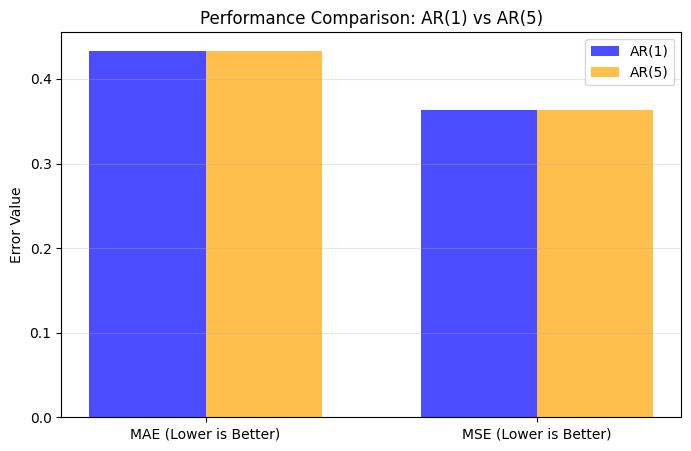

In [24]:
metrics = ["MAE (Lower is Better)", "MSE (Lower is Better)"]
ar1_vals = [mean_absolute_error(test_actual_close, ar1_price_preds), mean_squared_error(test_actual_close, ar1_price_preds)]
ar5_vals = [mean_absolute_error(test_actual_close, ar5_price_preds), mean_squared_error(test_actual_close, ar5_price_preds)]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, ar1_vals, width, label='AR(1)', color='blue', alpha=0.7)
plt.bar(x + width/2, ar5_vals, width, label='AR(5)', color='orange', alpha=0.7)

plt.ylabel('Error Value')
plt.title('Performance Comparison: AR(1) vs AR(5)')
plt.xticks(x, metrics)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()